<img src="MASc_Immersion_week.png" alt="Poster" width="600">

> ### We must understand how respiratory or sexual events, which have a place in objective space, are drawn away from it the dream state, and settled in a different theatre. But we shall not succeed in doing so unless we endow the body, even in the waking state, with an emblematic value. The movement upwards as a direction in physical space, and that of desire towards its objective, are mutually symbolical, because they both express the same essential structure of our being.... The phantasms of dreaming, of mythology, the favorite images of each man orindeed poetic imagery, are not linked to their meaning by a relation of sign to significance, like the one existing between a telephone number and the name of the subscriber; they really contain their meaning, which is not a notional meaning, but a direction of our existence.(284-285)

-- Merleau-Ponty, Maurice. <i>Phenomenology of Perception</i>. 1945. Trans. Colin Smith. London: Routledge, 1962.

# Install libraries and import dream data

In [17]:
!pip install wordcloud
from scipy.stats import entropy
import requests
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, power_divergence
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Video, display
from IPython.display import HTML
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

url = "https://github.com/texturejc/dreaming_allowed/releases/download/dreams_data/small_dreams_with_frames.pkl"

print("Downloading data...")
response = requests.get(url)

df = pd.read_pickle('small_dreams_with_frames.pkl')



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [18]:
len(df)

37715

## Investigate the data

In [ ]:
# Get first five rows
df.head()

In [ ]:
# Get data dimensions
df.shape

In [ ]:
# Get summary statistics of data
df.describe()

In [ ]:
# Get full list of columns
for i in df.columns:
    print(i)

In [ ]:
print(df['study_name'].value_counts())
print("\n")
print(df['respondent'].value_counts())

In [ ]:
sns.displot(df['respondent'].value_counts(), kind = 'kde')

# <i>... Sweet Dreams (Are Made of This) ...</i>

In [ ]:
HTML("""<video width="600" controls autoplay loop muted><source src="sweet_dreams.mp4" type="video/mp4"></video>""")


# 1––Dreams senses and emotions over time

What would we predict about the changing emotional and sensory profile of dreams across different time periods? It's important to be principled and make predictions; otherwise we are just fishing for correlations.

## Sensory profiles

Let's take three senses as our starting point: <i>taste</i>, <i>hearing</i>, and <i>smell</i>. Make a prediction concerning the incidence of language associated with each of these senses in dream reports. How is it likely to change

* by season of the year?
* by day of the week?
* When are we likely to see the peak of each sense?

Support your predictions with an hypothesis.

Text(0.5, 1.0, 'Variance by season')

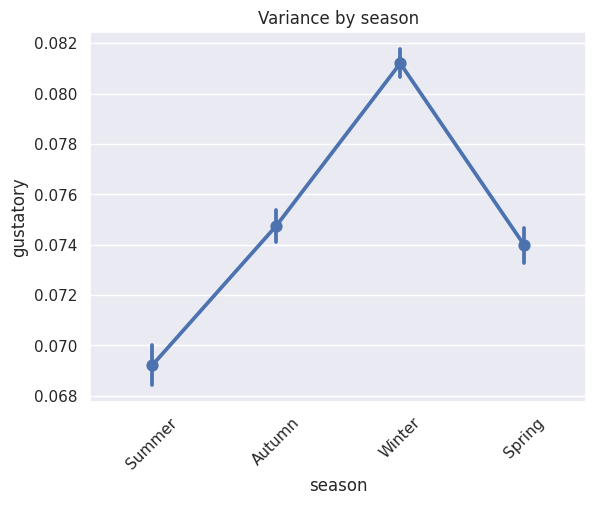

In [11]:
# Do initial plots to assess the data

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

variable = 'season'

sns.pointplot(x = variable, y = 'gustatory', order = season_order, data = df)
plt.xticks(rotation = 45)
plt.title("Variance by "+variable)

In [ ]:
len(df)

### Hypothesis testing

Though plots are a useful guide to the data, they are merely guidelines; to assess whether we are actually into something we need to conduct statistical tests. Here, we do this using what's called a <i>mixed linear model</i> (MLM). This accounts for the fact that our data are hierarchically nested in several levels: dreams within dreamers, and dreamers within studies.

In [10]:
dv = 'gustatory'

df_clean = df.dropna(subset=[dv, 'month_name', 'study_name', 'respondent']).copy()

# CREATE composite grouping variable
df_clean['study_dreamer'] = (
    df_clean['study_name'].astype(str) + '_' + 
    df_clean['respondent'].astype(str)
)

# Now fit with SINGLE grouping column
model = smf.mixedlm(
    f"{dv} ~ C(season)", 
    data=df_clean, 
    groups=df_clean["study_dreamer"] 
)

result = model.fit()
print(result.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   gustatory 
No. Observations:   37462     Method:               REML      
No. Groups:         10591     Scale:                0.0007    
Min. group size:    1         Log-Likelihood:       77056.6603
Max. group size:    940       Converged:            Yes       
Mean group size:    3.5                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.072    0.001 96.966 0.000  0.070  0.073
C(season)[T.Spring]  0.001    0.001  1.393 0.164 -0.001  0.003
C(season)[T.Summer] -0.004    0.001 -4.433 0.000 -0.006 -0.003
C(season)[T.Winter]  0.007    0.001  7.607 0.000  0.005  0.009
Group Var            0.001    0.001                           



## What about emotional profiles over time?

# <i>... California Dreamin' ...</i>

In [12]:
HTML("""<video width="600" controls autoplay loop muted><source src="California_Dreamin.mp4" type="video/mp4"></video>""")

# 2––Dream content by category

Should we expect dream content to differ by gender? And if so, in what ways? You can test for the linguistic variables previously explored on your own. Let's move now to the analysis of dream content. The challenge with analysing dream content is finding a way of identifying <i>scenarios</i> across dreams: focusing in words alone doesn't capture what intuitivelty seems to be core experence of the dream: being in a <i>situation</i>. Several schemas have been proposed to do this, with the most popular being the [Hall/Van de Castle](https://dreams.ucsc.edu/Coding/) coding. However, nearly all of these suffer from two two problems: first, they are somewhat arbitrary; and second, they don't really establish a continuity between the experience of action in dreaming and waking life. What might we use instead?

In what follows, I ananyse dreams in terms of <i>semantic frames</i>. These are basically a small number of cognitive models underwriting recurring experiences that we use to understand words. In the words of Charles Fillmore, the founder of frame semantics:

>Words represent categorization of experience, and each of these categories are underlain by a motivating situation occurring against a background of knowledge and experience. With respect to word meanings, frame semantic research can be thought of as the effort to understand what reason a speech community might have found for creating the category represented by the word, and to explain the word’s meaning by presenting and clarifying that reason. (373)

––Fillmore, Charles (2006). Frame Semantics. In D. Geerarts (Ed.), Cognitive Linguistics: Basic Readings (pp. 373-400). Berlin: Mouton de Gruyter.

What does this look like in practice? Take the two sentences below:

* (1) A spirit of vigorous enterprise ruled the day
* (2) The magistrate awarded substantial damages to the plaintiff

Though both sentences describe very different surface-level scenarios, frame semantics argues that they are both base on the AUTHORITY frame. This can be see from the table below:


| Frame Element | Instance 1                          | Instance 2                  |
|:--------------|:------------------------------------|:----------------------------|
| Agent         | A spirit of vigorous enterprise     | The magistrate              |
| Theme         | The day                             | The defendent (implicit)    |
| Descriptor    | Vigorous                            | Substantial                 |
| Domain        | Time or (implicit) activities       | Legal judgment              |
| Source        | Not specified                       | Legal system                |

<center><b>Table 1.</b> Semantic Frame Annotation Using the AUTHORITY frame</center><br />



There are approximately 1,200 semantic frames on record for Englush; they can be found in exhaustive detail at [FrameNet](https://framenet.icsi.berkeley.edu/). Traditionally, extracting semantic frames from text was a slow, qualitative process. However, recent developments have seen the emergence of [deeep learning algorithms](https://arxiv.org/abs/2303.12788) that can do so reliably and automatically. 

The advantage of this for dream analysis should be clear: by providing an academically grounded repertoire of scenarios that can be extracted in a consistent way and which reflect the totality of human action, semantic frames give us a ready-made dream schema. In the analysis below, the extracted semantic frames are the result of 36 hours compute on an A100 Google Colab GPU.

## Gender

In the dream data, male and female categories of dreamer offer one target of analysis. There are of course many interesting questions that could be asked of non binary dreams, but a lot this data is fairly old so non-binary status was not reliably included. Here, our variable is 'Sex assigned at birth'; this confounds several identities, but is still worth testing for any signals. The key difference here is that we need to get the frequencies of semantic frames and adjust for the following issues:

* The dataset does nto consist of one dream per dreamer; instead, many dreams can come from a single dreamer. This means we must ensure that dreamer's preoccupations don't affect our conclusions if they are responsible for more than one dream.
* Dreams do not all come from the same study. Some are short, terse reports; others are long descriptive records. Because longer reports will give more semantic frames, we need to ensure that we take only studies with roughly equal males and females.

How do we do this? The key is to merge all the dreams of a single dreamer into on 'big' dream and use this as the unit of analysis. When these are then merged into the larger categogory of (say) all male dreams, we merge the set of the semantic frames associated with each dreamer. This stops us from overcounting semantic frames associated with a specific dreamer and taking that to be representative of 'male' dreaming. We are looking for variations in semantic frame usage by gender; we are less concerned with the absolute cnumber of frames in all dreams. 

### Data extraction

In [20]:
# These are the atudies I have already identified as having balanced cohorts

df = df.dropna(subset = ['Sex Assigned at Birth'])
balanced_cohorts = [
    '2010-08',  # 45% F
    '2011-04',  # 53% F
    '2011-05',  # 55% F
    '2012-01',  # 55% F
    '2013-10',  # 49% F
]

df = df[df['year_month'].isin(balanced_cohorts)]

### Statistical analysis

The statistical analysis below is what's known as a ${\chi}^2$ test; this tests if there's a difference between the observed frequency of some item across a number of categories relative to the expected frequency. Imagine tossing a coin 1,000 times: you would expect to see roughly 500 observations of heads and 500 observations of tails. If you saw 100 heads and 900 tails, you would conclude that the voing was biased. 

Here, We would expect to see roughly equal numbers of every frame across male and female. The ${\chi}^2$ test evaluates if we do or not, and if we don't which frames are responsible and the size of the effect. Don't worry about either the code or the test for now; the idea is to get a general sense of what's happening. 

In [22]:

# Chi-Squared Analysis for Semantic Frames by Categorical Variable

GROUPING_VARIABLE = 'Sex Assigned at Birth'  # # Change to whatever variable you choose

# Readable name for display
GROUPING_LABEL = 'Gender' # Note that much of the data were collected becore non-binary was an option

# Minimum dreamers per group (filter out small groups)
MIN_DREAMERS_PER_GROUP = 30  # ← ADJUST THIS!

def print_section(title, width=70, char='='):
    """Print formatted section header"""
    print(f"\n{char * width}")
    print(title)
    print(char * width)

def get_group_label(group_val):
    """Convert group value to readable label"""
    return str(group_val)

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================

print_section(f"CHI-SQUARED ANALYSIS: SEMANTIC FRAMES BY {GROUPING_LABEL.upper()}")
print(f"Accounts for: dreamer nesting, diary length, sample size")
print_section("")

print(f"Initial data:")
print(f"  {len(df)} dreams", end='')
if 'respondent' in df.columns:
    print(f" from {df['respondent'].nunique()} dreamers")
else:
    print()


# Filter to valid dreams (have frames)
df_valid = df[df['frames'].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

print_section(f"STEP 1: IDENTIFY GROUPS WITH INSUFFICIENT DATA")

# Count dreamers and dreams per group
if 'respondent' in df_valid.columns:
    group_summary = df_valid.groupby(GROUPING_VARIABLE).agg({
        'respondent': 'nunique',
        'answer_text': 'count'
    }).rename(columns={'respondent': 'n_dreamers', 'answer_text': 'n_dreams'})
    
    # Calculate dreams per dreamer
    group_summary['dreams_per_dreamer'] = group_summary['n_dreams'] / group_summary['n_dreamers']
    
    # Filter by dreamer count
    sufficient_groups = group_summary[group_summary['n_dreamers'] >= MIN_DREAMERS_PER_GROUP].index
    
    print(f"\nSample sizes by {GROUPING_LABEL.lower()} (threshold: {MIN_DREAMERS_PER_GROUP} dreamers):")
    print("-" * 70)
    
    for group_val in sorted(df_valid[GROUPING_VARIABLE].unique()):
        if group_val in group_summary.index:
            row = group_summary.loc[group_val]
            status = "✓ INCLUDED" if group_val in sufficient_groups else "✗ EXCLUDED"
            label = get_group_label(group_val)
            
            print(f"  {label:15s} ({GROUPING_VARIABLE}={group_val:2}): "
                  f"{row['n_dreamers']:5.0f} dreamers, {row['n_dreams']:5.0f} dreams "
                  f"({row['dreams_per_dreamer']:5.1f} per dreamer) - {status}")
else:
    # No dreamer ID - just count dreams
    group_summary = df_valid.groupby(GROUPING_VARIABLE).size().to_frame('n_dreams')
    sufficient_groups = group_summary[group_summary['n_dreams'] >= MIN_DREAMERS_PER_GROUP].index
    
    print(f"\nSample sizes by {GROUPING_LABEL.lower()} (threshold: {MIN_DREAMERS_PER_GROUP} dreams):")
    print("-" * 70)
    
    for group_val in sorted(df_valid[GROUPING_VARIABLE].unique()):
        if group_val in group_summary.index:
            row = group_summary.loc[group_val]
            status = "✓ INCLUDED" if group_val in sufficient_groups else "✗ EXCLUDED"
            label = get_group_label(group_val)
            
            print(f"  {label:15s} ({GROUPING_VARIABLE}={group_val}): "
                  f"{row['n_dreams']:5.0f} dreams - {status}")

# Filter to sufficient groups
df_clean = df_valid[df_valid[GROUPING_VARIABLE].isin(sufficient_groups)].copy()

print(f"\nFiltering results:")
print(f"  Included groups: {len(sufficient_groups)}")
print(f"  Excluded groups: {len(df_valid[GROUPING_VARIABLE].unique()) - len(sufficient_groups)}")
print(f"  Retained: {len(df_clean)} dreams ({len(df_clean)/len(df_valid)*100:.1f}%)")
print(f"  Excluded: {len(df_valid) - len(df_clean)} dreams ({(len(df_valid)-len(df_clean))/len(df_valid)*100:.1f}%)")

# ============================================================================
# BUILD CONTINGENCY TABLE
# ============================================================================

print_section(f"STEP 2: BUILD DREAMER-LEVEL CONTINGENCY TABLE")

# For each dreamer-group, record which frames they used
if 'respondent' in df_clean.columns:
    dreamer_frame_presence = []
    
    for (dreamer, group_val), group_df in df_clean.groupby(['respondent', GROUPING_VARIABLE]):
        # Get all unique frames this dreamer used in this group
        all_frames = set()
        for frames_list in group_df['frames']:
            if isinstance(frames_list, list):
                all_frames.update(frames_list)
        
        # Create binary indicators for each frame
        for frame in all_frames:
            dreamer_frame_presence.append({
                'dreamer': dreamer,
                'group': group_val,
                'frame': frame,
                'present': 1
            })
    
    dreamer_frame_df = pd.DataFrame(dreamer_frame_presence)
    
    # Count dreamers using each frame in each group
    dreamer_contingency = dreamer_frame_df.groupby(['group', 'frame']).size().reset_index(name='n_dreamers')
else:
    # No dreamer nesting - use dream-level counts
    dream_frame_presence = []
    
    for idx, row in df_clean.iterrows():
        group_val = row[GROUPING_VARIABLE]
        if isinstance(row['frames'], list):
            for frame in set(row['frames']):  # Unique frames per dream
                dream_frame_presence.append({
                    'group': group_val,
                    'frame': frame,
                    'present': 1
                })
    
    dreamer_frame_df = pd.DataFrame(dream_frame_presence)
    dreamer_contingency = dreamer_frame_df.groupby(['group', 'frame']).size().reset_index(name='n_dreamers')

# Pivot to contingency table
contingency_table = dreamer_contingency.pivot_table(
    index='group',
    columns='frame',
    values='n_dreamers',
    fill_value=0
)

print(f"\nContingency table:")
print(f"  Rows ({GROUPING_LABEL.lower()}s): {len(contingency_table)}")
print(f"  Columns (frames): {len(contingency_table.columns)}")
print(f"  Cell values: Number of dreamers using each frame in each {GROUPING_LABEL.lower()}")
print(f"  Total observations: {contingency_table.sum().sum()}")

# ============================================================================
# OVERALL CHI-SQUARED TEST
# ============================================================================

print_section(f"STEP 3: OVERALL CHI-SQUARED TEST")

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

n_total = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f"\nTest results:")
print(f"  χ²({dof}) = {chi2:.2f}")
print(f"  p-value = {p_value:.4e}")
print(f"  Cramér's V = {cramers_v:.4f}")
print(f"  Variance explained: {cramers_v**2*100:.2f}%")

if p_value < 0.001:
    print(f"\n✓✓✓ HIGHLY SIGNIFICANT: Frame usage differs by {GROUPING_LABEL.lower()} (p < .001)")
elif p_value < 0.05:
    print(f"\n✓ SIGNIFICANT: Frame usage differs by {GROUPING_LABEL.lower()} (p < .05)")
else:
    print(f"\n✗ NOT SIGNIFICANT: No evidence of {GROUPING_LABEL.lower()} differences (p = {p_value:.3f})")

# Effect size interpretation
if cramers_v < 0.1:
    effect_desc = "negligible"
elif cramers_v < 0.3:
    effect_desc = "small to medium"
elif cramers_v < 0.5:
    effect_desc = "medium to large"
else:
    effect_desc = "large"

print(f"  Effect size: {effect_desc} (V = {cramers_v:.3f})")

# ============================================================================
# FRAME-SPECIFIC TESTS
# ============================================================================

print_section(f"STEP 4: FRAME-SPECIFIC TESTS")

frame_tests = []

# Get total dreamers/dreams per group
if 'respondent' in df_clean.columns:
    totals_by_group = df_clean.groupby(GROUPING_VARIABLE)['respondent'].nunique()
else:
    totals_by_group = df_clean.groupby(GROUPING_VARIABLE).size()

for frame in contingency_table.columns:
    # For this frame: how many dreamers used it in each group?
    used_counts = contingency_table[frame].values
    
    # How many total in each group?
    total_counts = np.array([totals_by_group[g] for g in contingency_table.index])
    
    # How many didn't use it?
    not_used_counts = total_counts - used_counts
    
    # Skip if too rare
    if used_counts.sum() < 5:
        continue
    
    # 2×k table: [used, not used] × [k groups]
    frame_table = np.array([used_counts, not_used_counts])
    
    try:
        chi2_frame, p_frame, _, _ = chi2_contingency(frame_table)
        
        # Calculate usage rates
        usage_rates = used_counts / total_counts
        max_group_idx = np.argmax(usage_rates)
        min_group_idx = np.argmin(usage_rates)
        
        frame_tests.append({
            'frame': frame,
            'chi2': chi2_frame,
            'p_value': p_frame,
            'n_total': int(used_counts.sum()),
            'mean_usage': usage_rates.mean(),
            'std_usage': usage_rates.std(),
            'max_usage': usage_rates[max_group_idx],
            'max_group': contingency_table.index[max_group_idx],
            'min_usage': usage_rates[min_group_idx],
            'min_group': contingency_table.index[min_group_idx],
            'range': usage_rates.max() - usage_rates.min()
        })
    except:
        continue

frame_tests_df = pd.DataFrame(frame_tests).sort_values('p_value')

# Bonferroni correction
bonferroni_alpha = 0.05 / len(frame_tests_df) if len(frame_tests_df) > 0 else 0.05
significant_frames = frame_tests_df[frame_tests_df['p_value'] < bonferroni_alpha]

print(f"\nTested {len(frame_tests_df)} frames")
print(f"Bonferroni-corrected α = {bonferroni_alpha:.4e}")
print(f"Significant frames: {len(significant_frames)} ({len(significant_frames)/len(frame_tests_df)*100:.1f}%)")

if len(significant_frames) > 0:
    print(f"\nTop 20 most variable frames:")
    print("-" * 70)
    
    # Add group labels
    significant_frames['max_group_name'] = significant_frames['max_group'].apply(get_group_label)
    significant_frames['min_group_name'] = significant_frames['min_group'].apply(get_group_label)
    
    display_df = significant_frames.head(20)[['frame', 'p_value', 'mean_usage', 
                                               'max_usage', 'max_group_name',
                                               'min_usage', 'min_group_name']].copy()
    
    # Format percentages
    display_df['mean_usage'] = display_df['mean_usage'].apply(lambda x: f"{x:.1%}")
    display_df['max_usage'] = display_df['max_usage'].apply(lambda x: f"{x:.1%}")
    display_df['min_usage'] = display_df['min_usage'].apply(lambda x: f"{x:.1%}")
    
    print(display_df.to_string(index=False))
else:
    print("\nNo frames significant after Bonferroni correction")

# ============================================================================
# PAIRWISE COMPARISONS
# ============================================================================

print_section(f"STEP 5: PAIRWISE {GROUPING_LABEL.upper()} COMPARISONS")

# Filter to frames with sufficient frequency
min_total_count = 10
min_groups_present = max(2, len(sufficient_groups) // 3)

frame_totals = contingency_table.sum(axis=0)
frame_presence = (contingency_table > 0).sum(axis=0)

valid_frames = frame_totals[
    (frame_totals >= min_total_count) & 
    (frame_presence >= min_groups_present)
].index

print(f"\nFiltering for pairwise comparisons:")
print(f"  Minimum total count: {min_total_count}")
print(f"  Minimum groups present: {min_groups_present}")
print(f"  Valid frames: {len(valid_frames)}/{len(contingency_table.columns)}")

contingency_filtered = contingency_table[valid_frames]


# ============================================================================
# FINAL SUMMARY
# ============================================================================

print_section("FINAL SUMMARY")

print(f"\nGrouping variable: {GROUPING_VARIABLE} ({GROUPING_LABEL})")
print(f"  Groups analyzed: {len(sufficient_groups)}")
print(f"  Total dreams: {len(df_clean)}")
if 'respondent' in df_clean.columns:
    print(f"  Total dreamers: {df_clean['respondent'].nunique()}")

print(f"\nOverall Test:")
print(f"  χ²({dof}) = {chi2:.2f}, p = {p_value:.4e}")
print(f"  Cramér's V = {cramers_v:.3f} ({effect_desc} effect)")
print(f"  Variance explained: {cramers_v**2*100:.2f}%")

print(f"\nFrame-Level:")
print(f"  {len(frame_tests_df)} frames tested")
print(f"  {len(significant_frames)} significant after Bonferroni correction ({len(significant_frames)/len(frame_tests_df)*100:.1f}%)")



print_section("ANALYSIS COMPLETE!", char='=')


CHI-SQUARED ANALYSIS: SEMANTIC FRAMES BY GENDER
Accounts for: dreamer nesting, diary length, sample size


Initial data:
  19728 dreams from 8035 dreamers

STEP 1: IDENTIFY GROUPS WITH INSUFFICIENT DATA

Sample sizes by gender (threshold: 30 dreamers):
----------------------------------------------------------------------
  Female          (Sex Assigned at Birth=Female):  4144 dreamers,  8827 dreams (  2.1 per dreamer) - ✓ INCLUDED
  Male            (Sex Assigned at Birth=Male):  3891 dreamers,  8355 dreams (  2.1 per dreamer) - ✓ INCLUDED

Filtering results:
  Included groups: 2
  Excluded groups: 0
  Retained: 19728 dreams (100.0%)
  Excluded: 0 dreams (0.0%)

STEP 2: BUILD DREAMER-LEVEL CONTINGENCY TABLE

Contingency table:
  Rows (genders): 2
  Columns (frames): 826
  Cell values: Number of dreamers using each frame in each gender
  Total observations: 80646.0

STEP 3: OVERALL CHI-SQUARED TEST

Test results:
  χ²(825) = 1690.84
  p-value = 6.4681e-62
  Cramér's V = 0.1448
  Varian

### How can we visualise the results? 

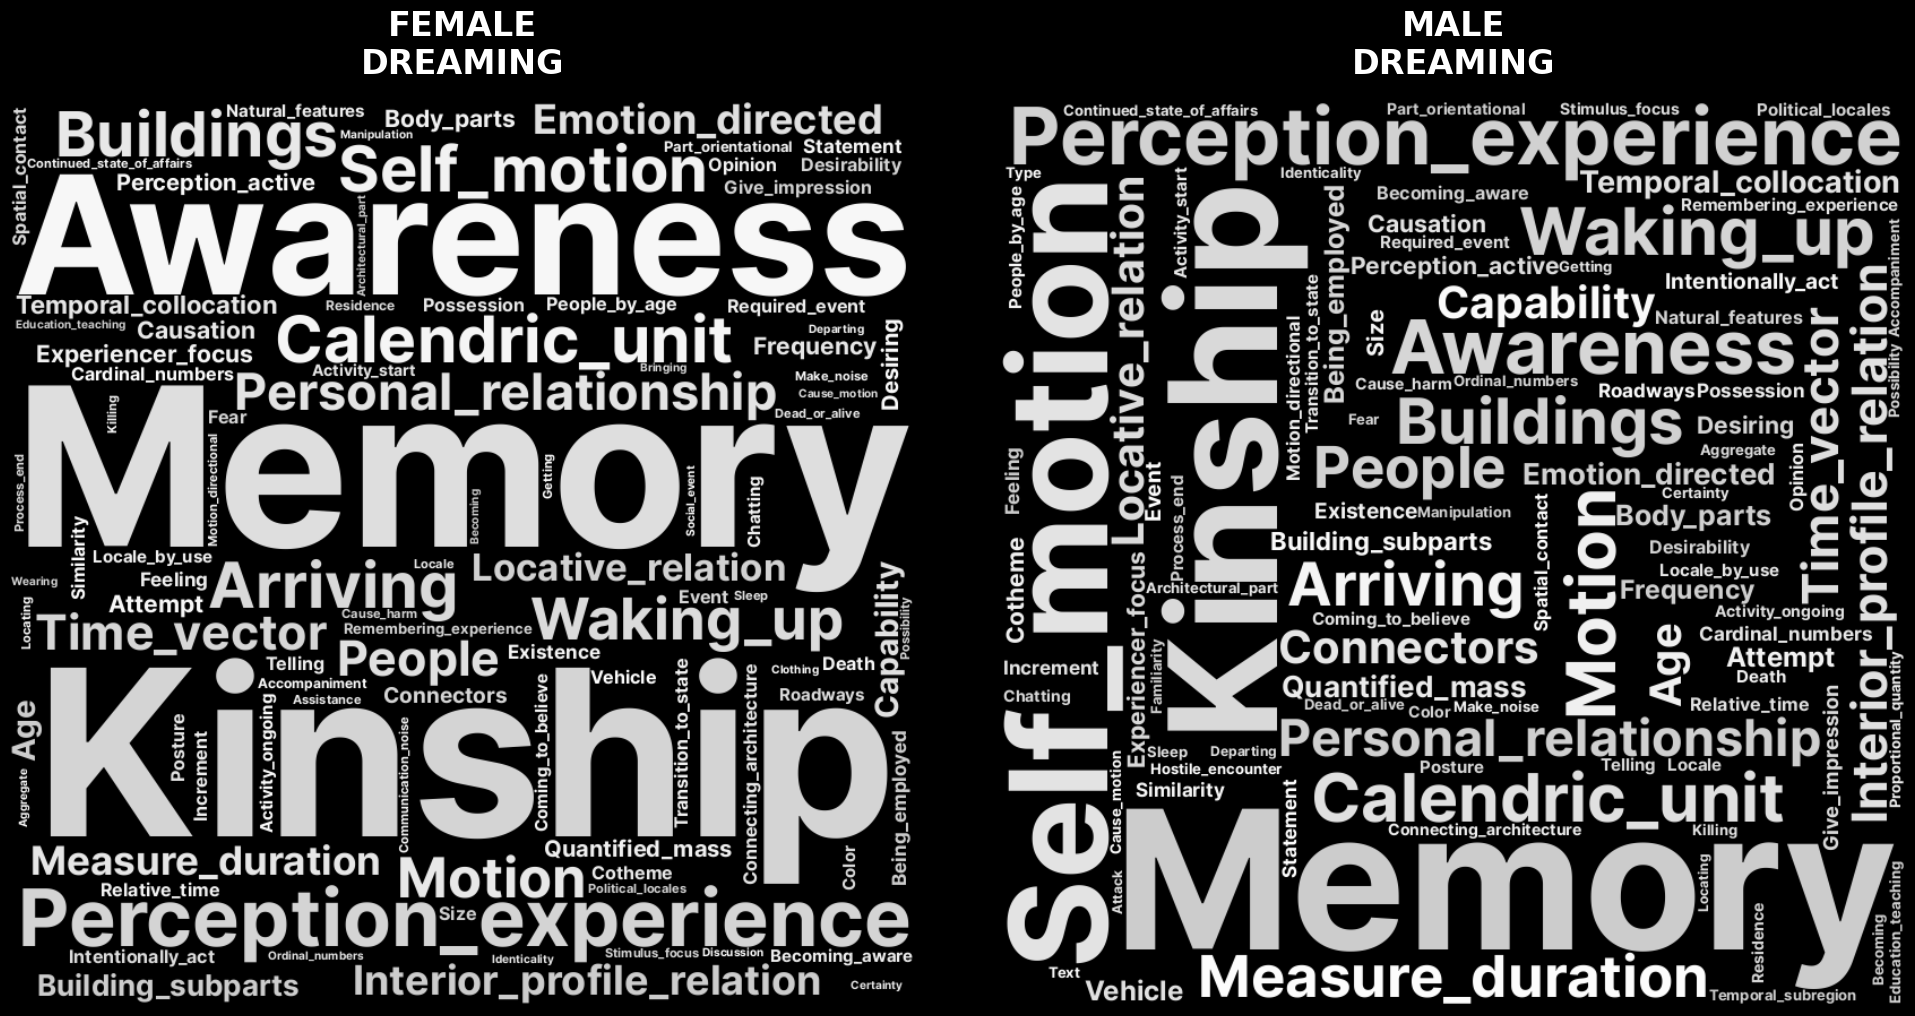

In [23]:
from wordcloud import WordCloud
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance


# Read the Excel file
d_ = pd.read_excel('contingency_gender.xlsx')
df_clean = d_.set_index('group').T

# Create word cloud data
female_data = df_clean['Female'].to_dict()
male_data = df_clean['Male'].to_dict()

# Apply power scaling
power = 2
female_scaled = {k: v**power for k, v in female_data.items()}
male_scaled = {k: v**power for k, v in male_data.items()}

# Custom color function for white/gray cloudy text
def cloudy_white(word, font_size, position, orientation, random_state=None, **kwargs):
    """Creates white to light gray colors with slight transparency variation"""
    lightness = np.random.randint(80, 100)  # 80-100% lightness (white to light gray)
    return f"hsl(0, 0%, {lightness}%)"

# Create figure with BLACK background
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')
fig.patch.set_facecolor('black')

# FEMALE Word Cloud - poster aesthetic
wc_female = WordCloud(
    width=800, 
    height=800,  # Made square like poster
    background_color='black',  # Black background
    color_func=cloudy_white,   # White/gray text
    relative_scaling=0.5,
    max_words=100,
    min_font_size=10,
    prefer_horizontal=0.7,     # Mix of orientations for cloud effect
    font_path="inter-bold.ttf"  # Use default or specify a bold sans-serif font
).generate_from_frequencies(female_scaled)

ax1.imshow(wc_female, interpolation='bilinear')
ax1.axis('off')
ax1.set_facecolor('black')
ax1.set_title('FEMALE\nDREAMING', size=24, pad=20, color='white', 
              fontweight='bold', fontfamily='sans-serif')

# MALE Word Cloud - poster aesthetic
wc_male = WordCloud(
    width=800, 
    height=800,
    background_color='black',
    color_func=cloudy_white,
    relative_scaling=0.5,
    max_words=100,
    min_font_size=10,
    prefer_horizontal=0.7,
    font_path="inter-bold.ttf"
).generate_from_frequencies(male_scaled)

ax2.imshow(wc_male, interpolation='bilinear')
ax2.axis('off')
ax2.set_facecolor('black')
ax2.set_title('MALE\nDREAMING', size=24, pad=20, color='white',
              fontweight='bold', fontfamily='sans-serif')

plt.tight_layout()
plt.savefig('dreaming_wordclouds_poster.png', 
            facecolor='black', 
            dpi=300, 
            bbox_inches='tight')
plt.show()

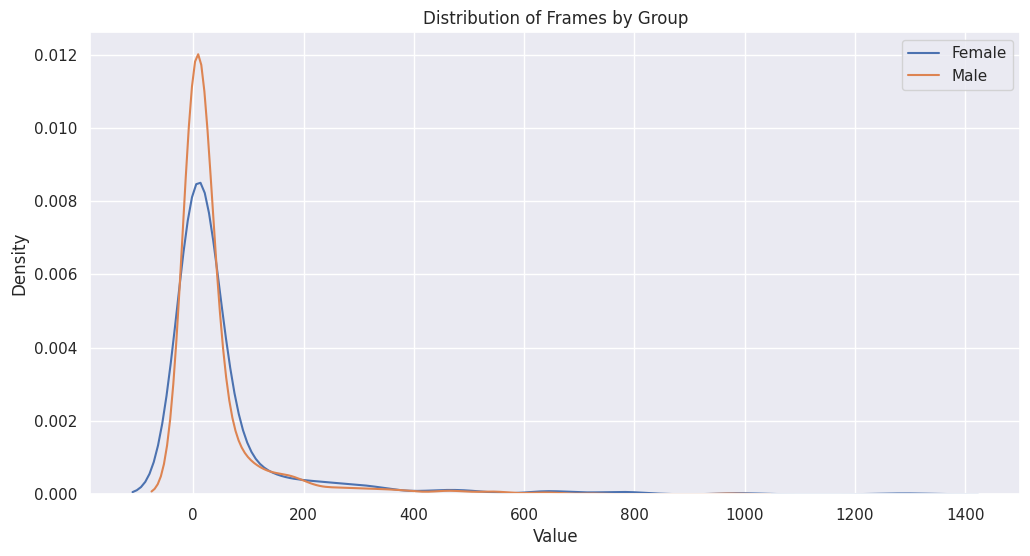

In [24]:
c_transposed = contingency_table.T

# Create the plot
plt.figure(figsize=(12, 6))
for group in c_transposed.columns:
    sns.kdeplot(data=c_transposed[group], label=group)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Distribution of Frames by Group')
plt.legend()
plt.show()

In [ ]:
H = entropy(contingency_table, axis = 1, base=2)
print("Female entropy is "+str(H[0]))
print("Male entropy is "+str(H[1]))

# Thunder only happens when it's raining ...

In [25]:
HTML("""<video width="600" controls autoplay loop muted><source src="Fleetwood.mp4" type="video/mp4"></video>""")